In [125]:
# !pip install yfinance

In [126]:
import yfinance as yf
import pandas as pd
import numpy as np

print("AI 반도체 대장주, SK하이닉스(000660) 주가 데이터를 불러옵니다...")

# 1. SK하이닉스 데이터 로드
hynix = yf.Ticker("000660.KS")
df = hynix.history(period="2y") # 최근 2년 데이터
df = df[['Close', 'Volume']] # 종가와 거래량만 사용

# 2. 기술적 지표 (20일 이동평균선)
df['MA20'] = df['Close'].rolling(window=20).mean()

# 3. 타겟 변수 설정: '내일'의 종가가 '내일'의 20일 이평선보다 높은가? (1: 상승돌파/유지, 0: 하락)
# 핵심: 오늘(t) 시점에서 내일(t+1)을 예측해야 하므로, 모델이 정답을 미리 보지 못하게 shift(-1) 적용
df['Target'] = (df['Close'].shift(-1) > df['MA20'].shift(-1)).astype(int)

print("데이터 로드 완료! 최근 5일 데이터를 확인합니다.")
print(df[['Close', 'MA20', 'Target']].tail())

np.random.seed(42)

# 1. 대안 데이터: NLP 감성 점수 시뮬레이션
# (실제로는 FinBERT로 크롤링한 뉴스 점수를 사용하지만, 실습 편의상 -1~1 사이 난수 생성)
df['NLP_Sentiment'] = np.random.uniform(-1, 1, len(df))

AI 반도체 대장주, SK하이닉스(000660) 주가 데이터를 불러옵니다...
데이터 로드 완료! 최근 5일 데이터를 확인합니다.
                              Close      MA20  Target
Date                                                 
2026-03-27 00:00:00+09:00  933000.0  954150.0       0
2026-03-30 00:00:00+09:00  873000.0  944750.0       0
2026-03-31 00:00:00+09:00  807000.0  938150.0       0
2026-04-01 00:00:00+09:00  897000.0  940550.0       0
2026-04-02 00:00:00+09:00  841000.0  935550.0       0


In [127]:
# !pip install OpenDartReader

In [128]:
import OpenDartReader
import datetime
import os
from dotenv import load_dotenv

# 1. .env 파일에 숨겨둔 환경 변수를 파이썬으로 불러오기
load_dotenv()

# 2. os 모듈을 통해 API 키 꺼내오기
# 코드 어디에도 실제 API 키 문자열이 노출되지 않습니다!
my_api_key = os.environ.get('api_key')

# API 키가 정상적으로 로드되었는지 확인 (키의 앞 5자리만 출력하여 보안 유지)
if my_api_key:
    print(f"API Key 로드 성공: {my_api_key[:5]}********")
else:
    print("오류: .env 파일에서 DART_API_KEY를 찾을 수 없습니다.")
# 시차 정보 제거 (tz-aware -> tz-naive)
df.index = df.index.tz_localize(None)
df = df.sort_index()

# 2. DART 데이터 수집 (현재 시간 기준 동적 할당)
dart = OpenDartReader(my_api_key)

# 🚨 핵심 수정: 코드를 실행하는 '현재 연도'를 기준으로 최근 3년(예: 2024, 2025, 2026) 계산
current_year = datetime.datetime.now().year
years = [str(current_year - 2), str(current_year - 1), str(current_year)]

reprt_codes = ['11013', '11012', '11014', '11011']
dart_data_list = []

print(f"금감원 DART 서버에서 실적 데이터를 수집 중입니다... 대상 연도: {years}")

for year in years:
    for code in reprt_codes:
        try:
            report = dart.finstate('000660', year, reprt_code=code)
            if report is not None:
                op_profit = report[(report['fs_div'] == 'CFS') & (report['account_nm'] == '영업이익')]
                if not op_profit.empty:
                    val = int(op_profit['thstrm_amount'].values[0].replace(',', ''))
                    
                    if code == '11013': d = f"{year}-05-15"
                    elif code == '11012': d = f"{year}-08-14"
                    elif code == '11014': d = f"{year}-11-14"
                    elif code == '11011': d = f"{str(int(year)+1)}-03-31" # 사업보고서는 다음 해 3월
                    
                    # 아직 미래의 날짜(예: 2026년 8월 14일)인 공시일은 제외하는 로직 추가
                    report_date = pd.to_datetime(d)
                    if report_date <= datetime.datetime.now():
                        dart_data_list.append({'Date': report_date, 'Operating_Profit': val})
        except: continue

dart_df = pd.DataFrame(dart_data_list).sort_values('Date')

# 3. pd.merge_asof를 이용한 시계열 병합
# merge_asof는 'Date'라는 독립된 컬럼이나 index끼리 병합할 수 있습니다.
# 여기서는 df의 index와 dart_df의 'Date' 컬럼을 병합합니다.
df = pd.merge_asof(df, dart_df, left_index=True, right_on='Date', direction='backward')

# 병합 과정에서 풀려버린 인덱스를 다시 Date로 설정
df.set_index('Date', inplace=True)

print("동적 연도 할당 및 데이터 병합 완료!")
display(df[['Close', 'Operating_Profit']].tail(10))

API Key 로드 성공: db4be********
금감원 DART 서버에서 실적 데이터를 수집 중입니다... 대상 연도: ['2024', '2025', '2026']
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
{'status': '013', 'message': '조회된 데이타가 없습니다.'}
동적 연도 할당 및 데이터 병합 완료!


,Close,Operating_Profit
Date,,
2026-03-20,1007000.0,1.138339e+13
2026-03-23,933000.0,1.138339e+13
2026-03-24,986000.0,1.138339e+13
2026-03-25,995000.0,1.138339e+13
2026-03-26,933000.0,1.138339e+13
2026-03-27,933000.0,1.138339e+13
2026-03-30,873000.0,1.138339e+13
2026-03-31,807000.0,4.720632e+13
2026-04-01,897000.0,4.720632e+13


In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. 입력 변수(X)와 타겟 변수(y) 분리
# 주의: 'Close' 가격 자체는 넣지 않습니다! (가격의 절대적 크기가 모델에 혼란을 줌)
feature_cols = ['Volume', 'MA20', 'NLP_Sentiment', 'Operating_Profit']
X = df[feature_cols]
y = df['Target']

# 2. 시계열 데이터 분할 (Time-Series Split)
# 랜덤하게 섞으면(train_test_split) 미래 데이터로 과거를 학습하는 대참사가 발생합니다.
# 반드시 시간 순서대로 앞부분 80%를 학습, 뒷부분 20%를 테스트로 나눕니다.
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. 모델 학습 (랜덤포레스트)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. 예측 및 평가
predictions = model.predict(X_test)

print("[주가 방향성(이평선 돌파) 예측 모델 성적표]")
print(f"정확도(Accuracy): {accuracy_score(y_test, predictions)*100:.2f}%")
print("\n상세 리포트:\n", classification_report(y_test, predictions))

[주가 방향성(이평선 돌파) 예측 모델 성적표]
정확도(Accuracy): 71.13%

상세 리포트:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.71      1.00      0.83        69

    accuracy                           0.71        97
   macro avg       0.36      0.50      0.42        97
weighted avg       0.51      0.71      0.59        97



c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [130]:
# 클래스 가중치 부여 (하락을 못 맞추면 페널티 부여!)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("[가중치 적용 후] 주가 방향성 예측 모델 성적표")
print(classification_report(y_test, predictions))

[가중치 적용 후] 주가 방향성 예측 모델 성적표
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.71      1.00      0.83        69

    accuracy                           0.71        97
   macro avg       0.36      0.50      0.42        97
weighted avg       0.51      0.71      0.59        97



c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [131]:

# 1. 주가와 거래량을 '전일 대비 수익률/변화율(%)'로 변환
df['Return'] = df['Close'].pct_change()
df['Volume_Change'] = df['Volume'].pct_change()

# 2. 이동평균선(MA20)은 절대 수치 대신 '이격도'로 변환
# 이격도: 현재 주가가 20일 이평선으로부터 위/아래로 몇 %나 떨어져 있는가?
df['Dist_MA20'] = (df['Close'] - df['MA20']) / df['MA20']

# 결측치(초기 변환 시 발생하는 NaN) 다시 제거
df.dropna(inplace=True)

print("절대 수치가 비율(%) 데이터로 완벽하게 변환되었습니다!")
display(df[['Close', 'Return', 'Volume_Change', 'Dist_MA20', 'NLP_Sentiment']].tail())


# X 변수 교체: 절대 가격이 들어간 변수는 과감히 버리고, 우리가 만든 비율 변수만 넣습니다.
feature_cols = ['Return', 'Volume_Change', 'Dist_MA20', 'Operating_Profit', 'NLP_Sentiment']
X = df[feature_cols]
y = df['Target']

# 시계열 분할 (앞 80% 학습, 뒤 20% 테스트)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 모델 학습 (class_weight 옵션 유지)
model_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_final.fit(X_train, y_train)

# 결과 예측 및 성적표 확인
predictions_final = model_final.predict(X_test)

print("[정상성 확보 후] 주가 방향성 예측 모델 성적표")
print(classification_report(y_test, predictions_final))

절대 수치가 비율(%) 데이터로 완벽하게 변환되었습니다!


,Close,Return,Volume_Change,Dist_MA20,NLP_Sentiment
Date,,,,,
2026-03-27,933000.0,0.000000,-0.029970,-0.022166,0.046196
2026-03-30,873000.0,-0.064309,-0.004964,-0.075946,0.258797
2026-03-31,807000.0,-0.075601,0.599277,-0.139796,0.391497
2026-04-01,897000.0,0.111524,-0.130560,-0.046303,-0.090918
2026-04-02,841000.0,-0.062430,-0.438316,-0.101064,0.255116


[정상성 확보 후] 주가 방향성 예측 모델 성적표
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.90      0.89      0.90        64

    accuracy                           0.86        92
   macro avg       0.83      0.84      0.83        92
weighted avg       0.86      0.86      0.86        92



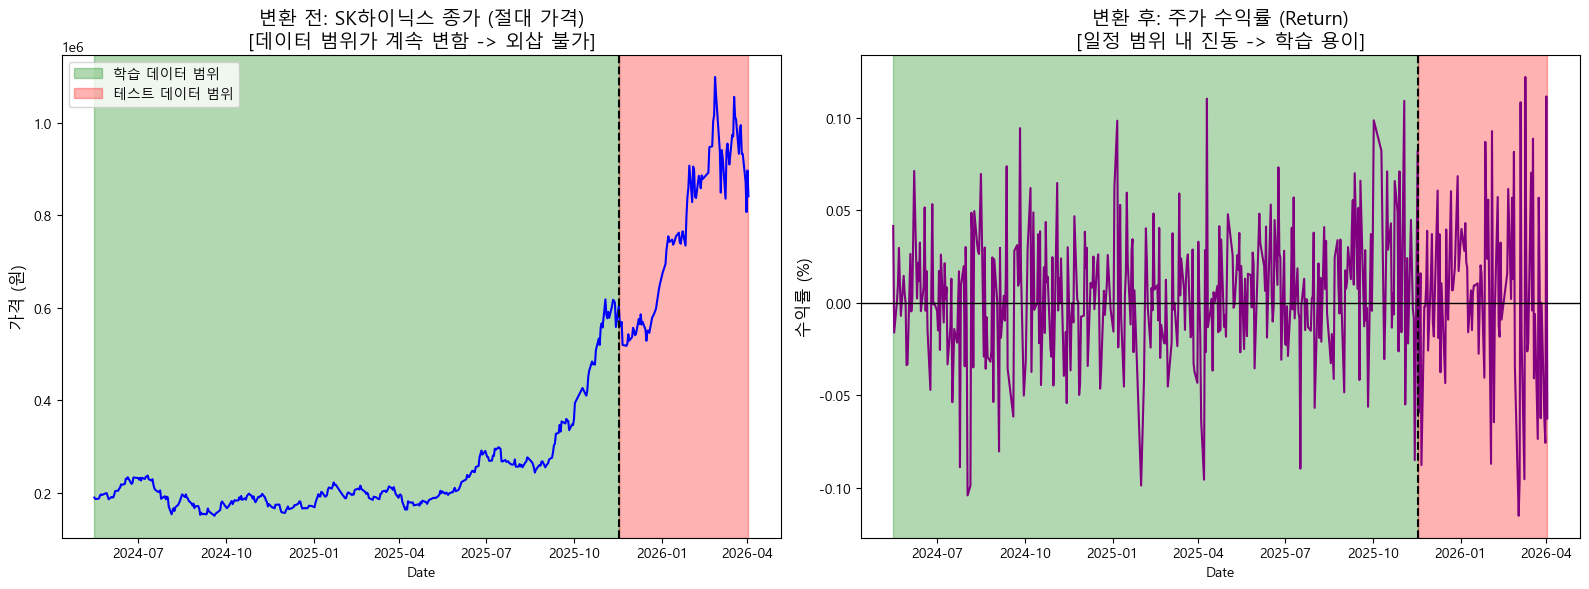

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 깨짐 방지 세팅 
plt.rc('font', family='Malgun Gothic')
# apple의 경우 
# plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
# 데이터를 '수익률'로 바꾸기 전(Close)과 후(Return)를 비교합니다.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 단위가 계속 커짐 (비정상성) -> AI가 외삽 불가
sns.lineplot(ax=axes[0], data=df, x=df.index, y='Close', color='blue')
axes[0].set_title(f'변환 전: SK하이닉스 종가 (절대 가격)\n[데이터 범위가 계속 변함 -> 외삽 불가]', fontsize=14)
axes[0].set_ylabel('가격 (원)', fontsize=12)

# 학습(Train)과 테스트(Test) 데이터를 시각적으로 구분
split_date = df.index[int(len(df) * 0.8)]
axes[0].axvspan(df.index[0], split_date, color='green', alpha=0.3, label='학습 데이터 범위')
axes[0].axvspan(split_date, df.index[-1], color='red', alpha=0.3, label='테스트 데이터 범위')
axes[0].axvline(x=split_date, color='black', linestyle='--')
axes[0].legend(loc='upper left')


# 해결책: 0을 기준으로 일정 범위 내 진동 (정상성 확보) -> AI가 학습 용이

sns.lineplot(ax=axes[1], data=df, x=df.index, y='Return', color='purple')
axes[1].set_title(f'변환 후: 주가 수익률 (Return)\n[일정 범위 내 진동 -> 학습 용이]', fontsize=14)
axes[1].set_ylabel('수익률 (%)', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1) # 기준선 0

# 학습/테스트 데이터 구분
axes[1].axvspan(df.index[0], split_date, color='green', alpha=0.3)
axes[1].axvspan(split_date, df.index[-1], color='red', alpha=0.3)
axes[1].axvline(x=split_date, color='black', linestyle='--')

plt.tight_layout()
plt.show()